# 🤖 Ejercicio Avanzado 2 — Machine Learning: predicción de recuperación de flotación
### Mina Wayra (ficticia) · *400 turnos simulados*

**Objetivo:** entrenar modelos que predigan la **recuperación de Au (%)** a partir de variables operativas (P80, pH, dosis de reactivos, % sólidos, ley, tiempo de residencia) y detectar cuáles variables importan más.

**Flujo de trabajo estándar de ML:**
1. EDA (análisis exploratorio) → 2. train/test split → 3. entrenar modelos → 4. evaluar → 5. interpretar

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel("../data/06_flotacion_ml_wayra.xlsx", sheet_name="datos_operativos")
df = df.drop(columns="turno_id")
df.describe().round(2)

,p80_um,ph_pulpa,dosis_colector_g_t,dosis_espumante_g_t,pct_solidos,ley_cabeza_au_g_t,tiempo_residencia_min,recuperacion_au_pct
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,73.92,10.16,28.11,14.08,34.12,4.55,21.79,96.88
std,12.36,0.48,6.27,3.03,2.85,0.88,2.93,0.51
min,45.00,8.80,12.00,6.00,25.80,2.52,14.10,92.59
25%,66.12,9.83,24.28,12.00,32.10,3.93,19.70,97.00
50%,73.75,10.22,28.20,14.00,34.10,4.54,21.70,97.00
75%,81.70,10.49,32.40,16.30,36.10,5.14,23.62,97.00
max,110.00,11.60,44.60,23.20,42.00,7.06,32.00,97.00


## 1. EDA: matriz de correlación
La correlación de Pearson solo captura relaciones **lineales** — ojo: P80 y pH tienen un óptimo (relación en forma de ∩), que la correlación lineal subestima.

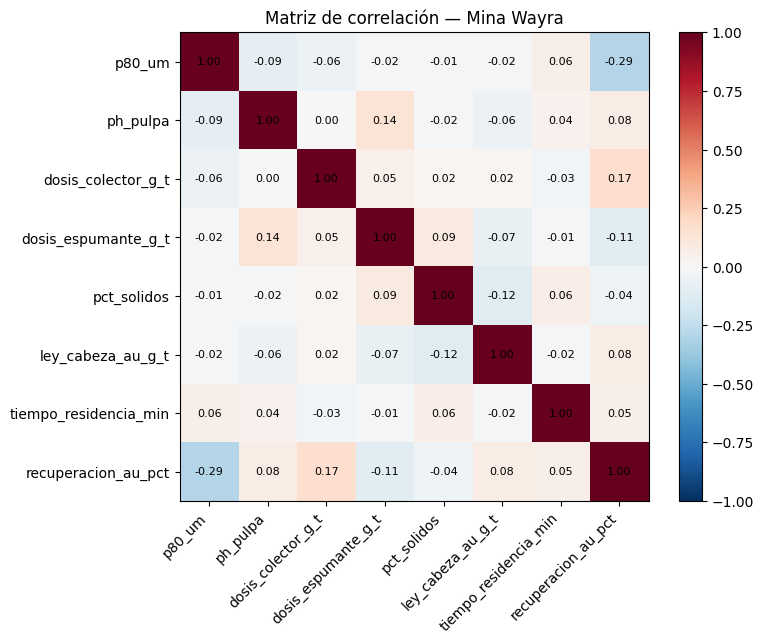

In [2]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(8, 6.5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im); plt.title("Matriz de correlación — Mina Wayra")
plt.tight_layout(); plt.show()

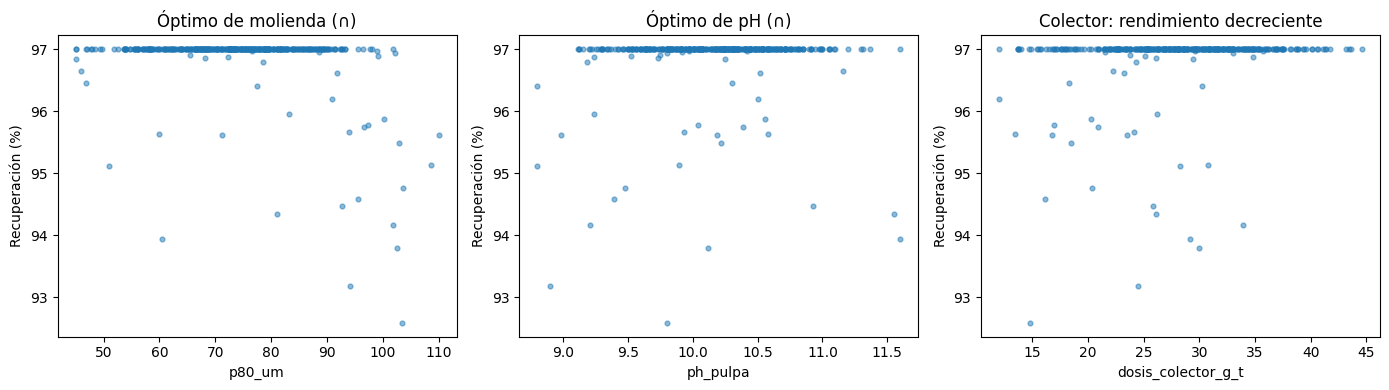

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, var in zip(axes, ["p80_um", "ph_pulpa", "dosis_colector_g_t"]):
    ax.scatter(df[var], df["recuperacion_au_pct"], s=12, alpha=0.5)
    ax.set_xlabel(var); ax.set_ylabel("Recuperación (%)")
axes[0].set_title("Óptimo de molienda (∩)"); axes[1].set_title("Óptimo de pH (∩)")
axes[2].set_title("Colector: rendimiento decreciente")
plt.tight_layout(); plt.show()

## 2. Train/test split
Separamos 25 % de los datos que el modelo **nunca ve** durante el entrenamiento — es la única forma honesta de medir si generaliza.

In [4]:
from sklearn.model_selection import train_test_split

X = df.drop(columns="recuperacion_au_pct")
y = df["recuperacion_au_pct"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print(f"Entrenamiento: {len(X_train)} turnos | Prueba: {len(X_test)} turnos")

Entrenamiento: 300 turnos | Prueba: 100 turnos


## 3. Modelo 1: Regresión lineal (línea base)

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

lin = LinearRegression().fit(X_train, y_train)
pred_lin = lin.predict(X_test)
print(f"Regresión lineal → R² = {r2_score(y_test, pred_lin):.3f} | "
      f"MAE = {mean_absolute_error(y_test, pred_lin):.2f} puntos de recuperación")

Regresión lineal → R² = 0.000 | MAE = 0.23 puntos de recuperación


## 4. Modelo 2: Random Forest
Un bosque de árboles de decisión captura relaciones **no lineales** (los óptimos de P80 y pH) sin que se las especifiquemos.

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=300, random_state=42).fit(X_train, y_train)
pred_rf = rf.predict(X_test)
print(f"Random Forest → R² = {r2_score(y_test, pred_rf):.3f} | "
      f"MAE = {mean_absolute_error(y_test, pred_rf):.2f} puntos de recuperación")

Random Forest → R² = 0.244 | MAE = 0.11 puntos de recuperación


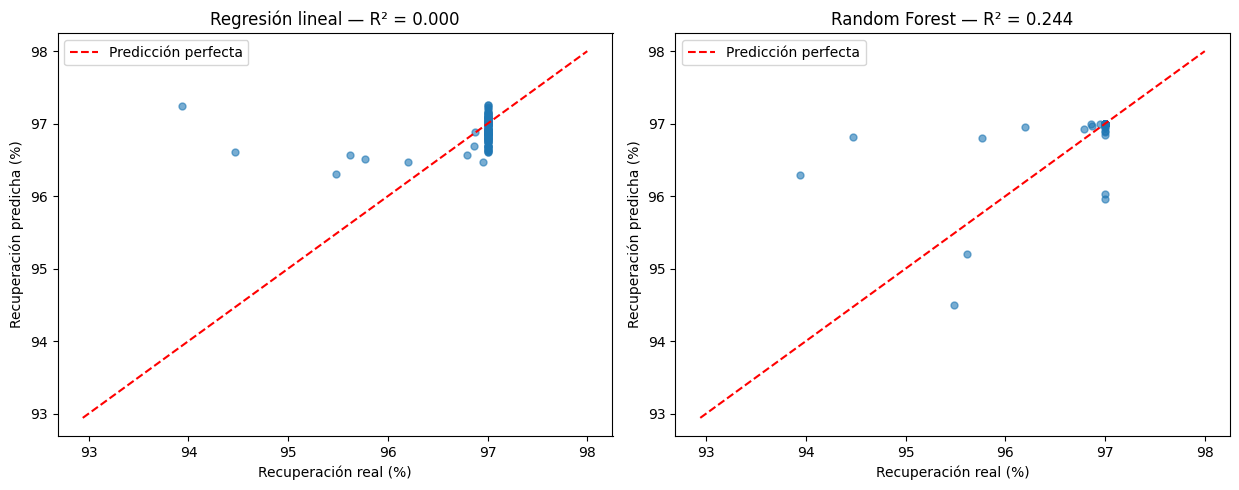

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5))
for ax, pred, titulo in [(axes[0], pred_lin, "Regresión lineal"),
                         (axes[1], pred_rf, "Random Forest")]:
    ax.scatter(y_test, pred, s=25, alpha=0.6)
    lims = [y_test.min() - 1, y_test.max() + 1]
    ax.plot(lims, lims, "r--", label="Predicción perfecta")
    ax.set_xlabel("Recuperación real (%)"); ax.set_ylabel("Recuperación predicha (%)")
    ax.set_title(f"{titulo} — R² = {r2_score(y_test, pred):.3f}")
    ax.legend()
plt.tight_layout(); plt.show()

## 5. ¿Qué variables controlan la recuperación?
La **importancia de variables** del Random Forest ordena qué medir/controlar primero en planta.

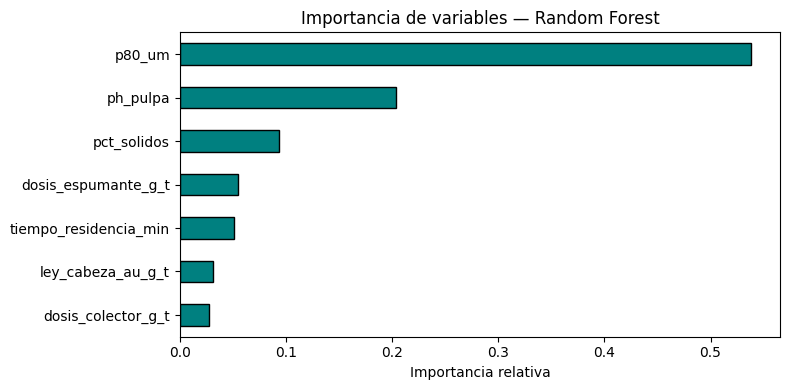

p80_um                   0.539
ph_pulpa                 0.203
pct_solidos              0.094
dosis_espumante_g_t      0.055
tiempo_residencia_min    0.051
ley_cabeza_au_g_t        0.031
dosis_colector_g_t       0.027
dtype: float64


In [8]:
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind="barh", color="teal", edgecolor="k", figsize=(8, 4))
plt.xlabel("Importancia relativa"); plt.title("Importancia de variables — Random Forest")
plt.tight_layout(); plt.show()
print(imp.sort_values(ascending=False).round(3))

## 6. Simulador: ¿qué recuperación esperar en un turno nuevo?

Recuperación estimada: 97.0 %


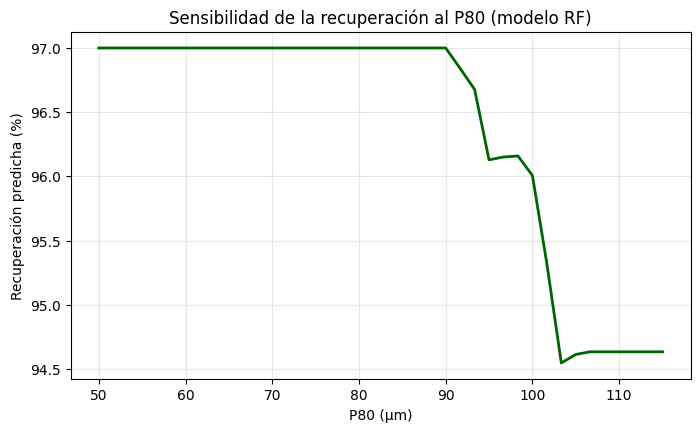

In [9]:
turno_nuevo = pd.DataFrame([{
    "p80_um": 72, "ph_pulpa": 10.3, "dosis_colector_g_t": 30,
    "dosis_espumante_g_t": 14, "pct_solidos": 34,
    "ley_cabeza_au_g_t": 5.0, "tiempo_residencia_min": 24,
}])
print(f"Recuperación estimada: {rf.predict(turno_nuevo)[0]:.1f} %")

# Sensibilidad al P80 manteniendo lo demás constante
p80s = np.linspace(50, 115, 40)
sens = pd.concat([turno_nuevo] * 40, ignore_index=True)
sens["p80_um"] = p80s
plt.figure(figsize=(8, 4.5))
plt.plot(p80s, rf.predict(sens), lw=2, color="darkgreen")
plt.xlabel("P80 (µm)"); plt.ylabel("Recuperación predicha (%)")
plt.title("Sensibilidad de la recuperación al P80 (modelo RF)")
plt.grid(alpha=0.3); plt.show()

## ✅ Conclusiones
1. El Random Forest supera a la regresión lineal porque la flotación tiene óptimos no lineales (P80, pH).
2. Las variables más importantes son P80 y pH → donde el metalurgista debe enfocar el control.
3. El modelo sirve como **simulador de escenarios** antes de mover variables en la planta real.

**Siguiente:** [Avanzado 3 — SQL desde cero](07_avanzado_sql_planta.ipynb)